Total airports: 463
Voronoi regions: 447


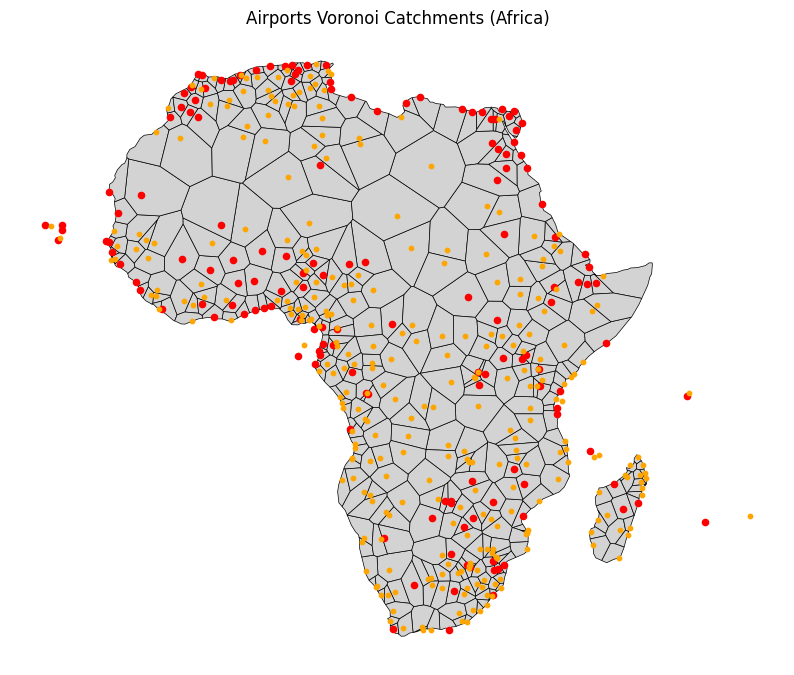

In [2]:
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point
from shapely.ops import voronoi_diagram
import matplotlib.pyplot as plt

# =========================
# 1. 读取机场数据
# =========================

def load_airports(path):
    df = pd.read_csv(path)
    df = df.dropna(subset=["iata_code", "longitude_deg", "latitude_deg"])
    df["geometry"] = df.apply(
        lambda r: Point(r["longitude_deg"], r["latitude_deg"]),
        axis=1
    )
    gdf = gpd.GeoDataFrame(
        df,
        geometry="geometry",
        crs="EPSG:4326"
    )
    def simplify_type(t):
        if t == "large_airport":
            return "large"
        elif t == "medium_airport":
            return "medium"
        else:
            return None
    gdf["airport_type"] = gdf["type"].apply(simplify_type)
    gdf = gdf.dropna(subset=["airport_type"])
    gdf = gdf.reset_index(drop=True)
    gdf["airport_id"] = gdf.index
    return gdf

# =========================
# 2. 读取并处理非洲边界
# =========================

def load_africa_boundary(path, target_crs):
    countries = gpd.read_file(path)
    africa = countries[countries["CONTINENT"] == "Africa"]
    africa = africa.dissolve()
    africa = africa.to_crs(target_crs)
    africa["geometry"] = africa.geometry.simplify(
        tolerance=0.05,
        preserve_topology=True
    )
    return africa

# =========================
# 3. 构建 Voronoi
# =========================

def build_airport_voronoi(airports, africa_boundary):
    # # 只选 large 机场
    # large_airports = airports[airports["airport_type"] == "large"].copy()
    # # 合并大机场点
    # points = large_airports.geometry.union_all()
    airports = airports[(airports["continent"] == "AF") &(airports["iso_country"] != "ES")]
    points = airports.geometry.union_all()

    # 生成 Voronoi（限定在非洲 envelope）
    vor = voronoi_diagram(
        points,
        envelope=africa_boundary.geometry.union_all()
    )
    vor_polys = gpd.GeoDataFrame(
        geometry=list(vor.geoms),
        crs=airports.crs
    )
    # 空间匹配 Voronoi 到 large 机场
    vor_joined = gpd.sjoin(
        vor_polys,
        airports[["airport_id","iata_code","airport_type","geometry"]],
        how="left",
        predicate="intersects"
    )

    # 裁剪到非洲边界
    vor_clipped = gpd.overlay(
        vor_joined,
        africa_boundary,
        how="intersection"
    )
    # dissolve 成每个大机场一个腹地
    vor_gdf = (
        vor_clipped
        .dissolve(by="airport_id", as_index=False)
        .merge(
            airports.drop(columns="geometry"),
            on="airport_id",
            how="left"
        )
    )
    vor_gdf = gpd.GeoDataFrame(
        vor_gdf,
        geometry="geometry",
        crs=airports.crs
    )

    return vor_gdf, airports


# =========================
# 4. 主流程
# =========================

airports = load_airports("../input/AfricanAirpots.csv")
africa = load_africa_boundary(
    "../input/ne_110m_admin_0_countries/ne_110m_admin_0_countries.shp",
    airports.crs
)
vor_gdf, airports = build_airport_voronoi(airports, africa)
print("Total airports:", len(airports))
print("Voronoi regions:", len(vor_gdf))


# =========================
# 5. 可视化
# =========================

fig, ax = plt.subplots(figsize=(10, 10))
vor_gdf.plot(
    ax=ax,
    facecolor="lightgrey",
    edgecolor="black",
    linewidth=0.5
)
airports[airports['type']=='large_airport'].plot(
    ax=ax,
    color="red",
    markersize=20
)
airports[airports['type']=='medium_airport'].plot(
    ax=ax,
    color="orange",
    markersize=10
)
ax.set_title("Airports Voronoi Catchments (Africa)")
ax.set_axis_off()
plt.show()

In [3]:
import geopandas as gpd
import rasterio
from rasterstats import zonal_stats
import numpy as np


# =========================
# 1. 读取人口栅格
# =========================
pop_path = "../input/global_pop_2025_CN_1km_R2025A_UA_v1.tif"
with rasterio.open(pop_path) as src:
    raster_crs = src.crs
    print("Raster CRS:", raster_crs)
# =========================
# 2. 确保 Voronoi 与 raster CRS 一致
# =========================
if vor_gdf.crs != raster_crs:
    vor_gdf = vor_gdf.to_crs(raster_crs)
# =========================
# 3. Zonal population sum
# =========================
stats = zonal_stats(
    vor_gdf,
    pop_path,
    stats=["sum"],
    nodata=-99999  # 如不确定可先打印 src.nodata
)
# 提取结果
pop_values = [s["sum"] if s["sum"] is not None else 0 for s in stats]
vor_gdf["pop_2025"] = np.array(pop_values)
print("Total population (sum of Voronoi):",
      vor_gdf["pop_2025"].sum())
print(vor_gdf.head())
# print(vor_gdf[["iata_code_x", "pop_2025"]].head())

Raster CRS: EPSG:4326
Total population (sum of Voronoi): 1500217638.374588
   airport_id                                           geometry  index_right  \
0           0  POLYGON ((37.71145 17.21714, 39.86593 14.59942...            0   
1           1  POLYGON ((38.5603 17.69877, 38.99062 16.84063,...            1   
2           2  POLYGON ((40.94084 11.6476, 40.88466 11.66047,...            2   
3           3  POLYGON ((30.51878 7.22739, 32.30404 7.20803, ...            3   
4           4  POLYGON ((28.86884 10.53728, 32.76103 12.07407...            4   

  iata_code_x airport_type_x       featurecla  scalerank  LABELRANK  \
0         ASM          large  Admin-0 country          1          3   
1         MSW         medium  Admin-0 country          1          3   
2         ASA          large  Admin-0 country          1          3   
3         JUB          large  Admin-0 country          1          3   
4         MAK         medium  Admin-0 country          1          3   

           

In [13]:
# vor_gdf[["ident", "pop_2025"]].to_csv(
#     "../airport_voronoi_population.csv",
#     index=False
# )

In [5]:
vor_gdf.columns

Index(['airport_id', 'geometry', 'index_right', 'iata_code_x',
       'airport_type_x', 'featurecla', 'scalerank', 'LABELRANK', 'SOVEREIGNT',
       'SOV_A3',
       ...
       'scheduled_service', 'icao_code', 'iata_code_y', 'gps_code',
       'local_code', 'home_link', 'wikipedia_link', 'keywords',
       'airport_type_y', 'pop_2025'],
      dtype='object', length=196)

In [4]:
# 假设 vor_gdf 已经有 pop_2025
# 从原 airports 表里抓 GDP per capita
gdp_df = airports[["iata_code", "GDPpercapita_2024"]].copy()
# merge 到 vor_gdf
vor_gdf = vor_gdf.merge(
    gdp_df,
    left_on="iata_code_x",
    right_on="iata_code",
    how="left"
)

# 计算机场质量
vor_gdf["mass"] = vor_gdf["pop_2025"] * vor_gdf["GDPpercapita_2024_y"]

# 查看前几条
print(vor_gdf[["iata_code", "pop_2025", "GDPpercapita_2024_y", "mass"]].head())

  iata_code      pop_2025  GDPpercapita_2024_y          mass
0       ASM  2.047982e+06                656.0  1.343476e+09
1       MSW  6.555206e+05                656.0  4.300215e+08
2       ASA  5.225520e+05                656.0  3.427941e+08
3       JUB  2.638915e+06                493.0  1.300985e+09
4       MAK  3.177270e+06                493.0  1.566394e+09


In [15]:
vor_gdf['latitude_deg']

0      15.291900
1      15.670000
2      13.071800
3       4.872010
4       9.558739
         ...    
442    -0.711739
443    -1.574730
444     0.579211
445     0.458600
446    -1.656160
Name: latitude_deg, Length: 447, dtype: float64

In [5]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize

# 假设 airports 已经准备好，包括
# 'airport_id', 'airport_type' ('large'/'medium'), 'mass', 'longitude_deg', 'latitude_deg'
airports = vor_gdf.copy()

n = len(airports)
mass = airports['mass'].values
lon = airports['longitude_deg'].values
lat = airports['latitude_deg'].values


# 计算距离矩阵
def haversine(lon1, lat1, lon2, lat2):
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return 6371 * c

dist_matrix = np.zeros((n,n))
for i in range(n):
    dist_matrix[i, :] = haversine(lon[i], lat[i], lon, lat)

T_obs = 273_000_000  # 总客运量 2025

# 目标函数直接优化 α 和 xi
def objective(params):
    alpha, xi = params
    if alpha <= 0:  # α 必须正
        return 1e20
    G = np.zeros((n,n))
    for i in range(n):
        for j in range(n):
            if i==j or dist_matrix[i,j]<100:
                continue
            G[i,j] = mass[i]*mass[j]/(dist_matrix[i,j]**xi)
    T_pred = alpha * G.sum()
    return (T_pred - T_obs)**2

x0 = [1e-10, 1.0]  # 初值
bounds = [(1e-15, 1e-5), (0.1, 5)]  # α合理范围，xi合理范围

res = minimize(objective, x0=x0, bounds=bounds, method='L-BFGS-B')

alpha_opt, xi_opt = res.x
print("Optimized alpha:", alpha_opt)
print("Optimized xi:", xi_opt)

# 计算最终预测总量
G_final = np.zeros((n,n))
for i in range(n):
    for j in range(n):
        if i==j or dist_matrix[i,j]<100:
            continue
        G_final[i,j] = mass[i]*mass[j]/(dist_matrix[i,j]**xi_opt)
T_pred_final = alpha_opt * G_final.sum()

# ------------------------
# 输出误差
abs_error = T_pred_final - T_obs
rel_error = 100 * abs_error / T_obs
print(f"Absolute error: {abs_error:,.0f}")
print(f"Relative error: {rel_error:.2f}%")

Optimized alpha: 1e-15
Optimized xi: 0.4307412199037096
Absolute error: 10
Relative error: 0.00%


In [6]:
# ------------------------
# 4. 构建 OD 航段（hub-and-spoke）
# ------------------------
large_idx = airports[airports['airport_type_x']=='large'].index
medium_idx = airports[airports['airport_type_x']=='medium'].index

closest_large = {}
for i in medium_idx:
    d_to_large = dist_matrix[i, large_idx]
    closest_idx = large_idx[np.argmin(d_to_large)]
    closest_large[i] = closest_idx

OD_list = []
for i in range(n):
    for j in range(n):
        if i == j:
            continue
        vol = OD_travel[i, j]
        if vol == 0:
            continue
        origin_type = airports.loc[i, 'airport_type_x']
        dest_type = airports.loc[j, 'airport_type_x']

        if origin_type == 'large' and dest_type == 'large':
            OD_list.append({'OriginID': i, 'DestinationID': j, 'Vol': vol})
        elif origin_type == 'medium' and dest_type == 'large':
            if closest_large[i] == j:
                OD_list.append({'OriginID': i, 'DestinationID': j, 'Vol': vol})
            else:
                hub = closest_large[i]
                OD_list.append({'OriginID': i, 'DestinationID': hub, 'Vol': vol})
                OD_list.append({'OriginID': hub, 'DestinationID': j, 'Vol': vol})
        elif origin_type == 'large' and dest_type == 'medium':
            if closest_large[j] == i:
                OD_list.append({'OriginID': i, 'DestinationID': j, 'Vol': vol})
            else:
                hub = closest_large[j]
                OD_list.append({'OriginID': i, 'DestinationID': hub, 'Vol': vol})
                OD_list.append({'OriginID': hub, 'DestinationID': j, 'Vol': vol})
        elif origin_type == 'medium' and dest_type == 'medium':
            hub_i = closest_large[i]
            hub_j = closest_large[j]
            if hub_i == hub_j:
                OD_list.append({'OriginID': i, 'DestinationID': hub_i, 'Vol': vol})
                OD_list.append({'OriginID': hub_i, 'DestinationID': j, 'Vol': vol})
            else:
                OD_list.append({'OriginID': i, 'DestinationID': hub_i, 'Vol': vol})
                OD_list.append({'OriginID': hub_i, 'DestinationID': hub_j, 'Vol': vol})
                OD_list.append({'OriginID': hub_j, 'DestinationID': j, 'Vol': vol})

OD_df = pd.DataFrame(OD_list)
OD_summary = OD_df.groupby(['OriginID','DestinationID']).agg({'Vol':'sum'}).reset_index()

# ------------------------
# 5. 输出结果
# ------------------------
print("Total predicted passengers (sum over OD):", OD_summary['Vol'].sum())
error = OD_summary['Vol'].sum() - T_obs
print("Absolute error:", error)
print("Relative error (%):", 100*error/T_obs)

# LOS ↔ ACC 流量
idx_los = airports[airports['iata_code']=='LOS'].index[0]
idx_acc = airports[airports['iata_code']=='ACC'].index[0]
los_acc_vol = OD_summary[
    ((OD_summary['OriginID']==idx_los) & (OD_summary['DestinationID']==idx_acc)) |
    ((OD_summary['OriginID']==idx_acc) & (OD_summary['DestinationID']==idx_los))
]['Vol'].sum()
print("Predicted LOS ↔ ACC passengers:", los_acc_vol)

# 前十航线
top_pairs_idx = OD_summary.sort_values('Vol', ascending=False).head(10).index
print("\nTop 10 predicted passenger flows:")
for idx in top_pairs_idx:
    row = OD_summary.loc[idx]
    o = airports.loc[row['OriginID'], 'iata_code']
    d = airports.loc[row['DestinationID'], 'iata_code']
    v = row['Vol']
    print(f"{o} ↔ {d}: {v:,.0f}")

NameError: name 'OD_travel' is not defined

### Not used

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt

# 读取 GPKG 文件
# 如果 GPKG 中有多个图层，可以通过 layer 参数指定
fp = "../Africapolis_GIS_2024/Africapolis_GIS_2024.gpkg"
gdf = gpd.read_file(fp)  # 默认读取第一个图层

# 查看前几行数据
print(gdf.head())

# 查看图层信息
print(gdf.crs)  # 坐标参考系统
print(gdf.columns)  # 属性字段

In [17]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point

# 假设你的 DataFrame 叫 df
# 如果 geometry 列已经是 shapely 对象，可以直接这样做：
gdf = gpd.GeoDataFrame(gdf, geometry='geometry')

# # 快速可视化
# gdf.plot(figsize=(10,10), edgecolor='k', color='lightgreen')
# plt.title("Agglomerations Map")
# plt.show()

In [27]:
# vor_gdf: Voronoi, 含 'airport_id'
# agglom_gdf: Agglomeration, 含 'Population_2025','Population_2050'

# 1. 投影到平面 CRS (EPSG:6933) 仅为了距离计算或点落入多边形
vor_proj = vor_gdf.to_crs(epsg=6933)
agglom_proj = gdf.to_crs(epsg=6933)

# 2. 计算城市化区域中心点
agglom_proj["centroid"] = agglom_proj.geometry.centroid

# 3. 使用 spatial join，将中心点落入 Voronoi
centroids_gdf = gpd.GeoDataFrame(agglom_proj.drop(columns="geometry"),
                                 geometry=agglom_proj["centroid"],
                                 crs=agglom_proj.crs)

joined = gpd.sjoin(centroids_gdf, vor_proj[["airport_id","geometry"]], how="left", predicate="within")

# 4. 按 Voronoi 聚合人口
pop_2025 = joined.groupby("airport_id")["Population_2025"].sum()
pop_2050 = joined.groupby("airport_id")["Population_2050"].sum()

vor_gdf["pop_2025"] = vor_gdf["airport_id"].map(pop_2025).fillna(0)
vor_gdf["pop_2050"] = vor_gdf["airport_id"].map(pop_2050).fillna(0)

print(vor_gdf[["airport_id","pop_2025","pop_2050"]].head())

   airport_id    pop_2025    pop_2050
0           0   7934175.0  14678255.0
1           1    981896.0   1750456.0
2           2    539064.0   1145664.0
3           3  18659531.0  37678041.0
4           4   5169626.0   8243784.0


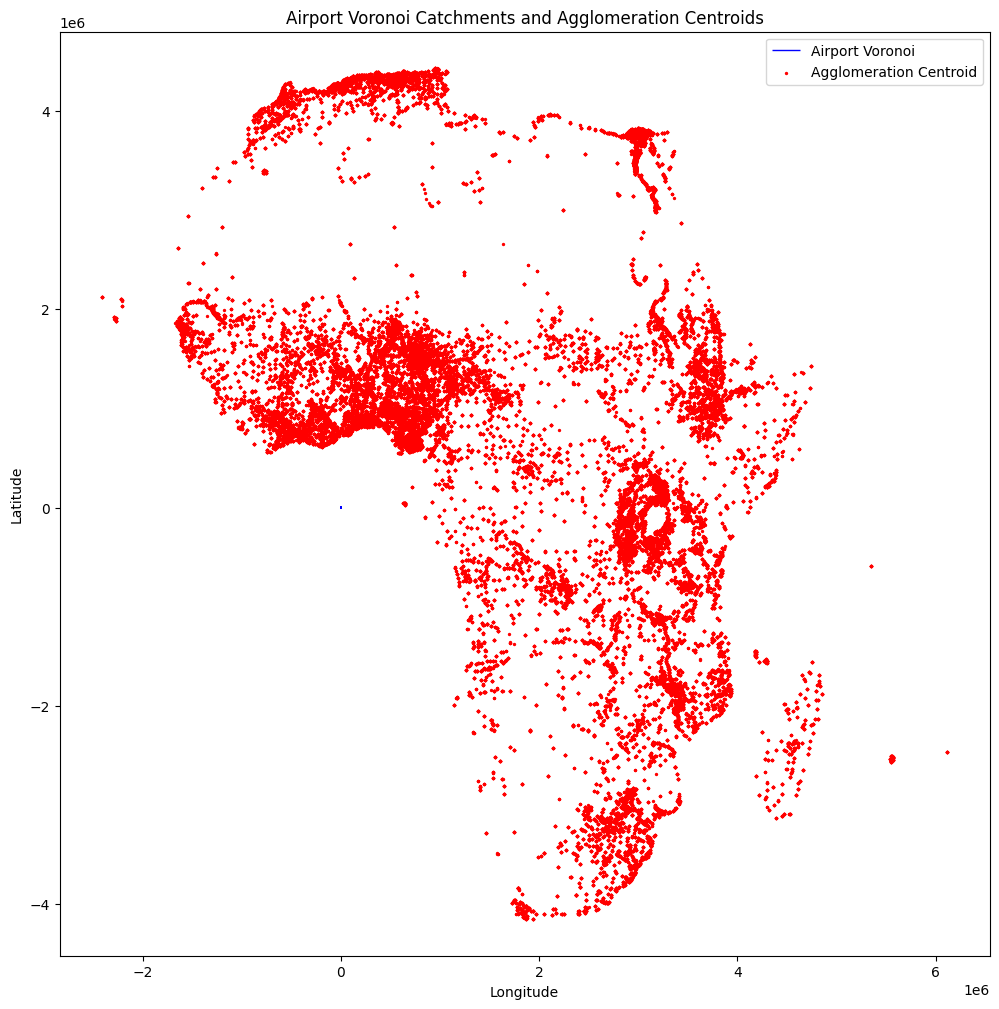

In [27]:
import geopandas as gpd
import matplotlib.pyplot as plt

# 假设数据已经准备好
# vor_gdf: Voronoi polygons, 含 'airport_id'
# agglom_gdf: Agglomeration polygons, 含 'Population_2025'
# agglom_gdf 已计算 centroid
agglom_proj['centroid'] = agglom_proj.geometry.centroid
centroids_gdf = gpd.GeoDataFrame(agglom_proj.drop(columns='geometry'),
                                 geometry=agglom_proj['centroid'],
                                 crs=agglom_proj.crs)

# 绘图
fig, ax = plt.subplots(figsize=(12, 12))

# 1. Voronoi 多边形
vor_gdf.boundary.plot(ax=ax, color='blue', linewidth=1, label='Airport Voronoi')

# # 2. Agglomeration 多边形
# agglom_proj.boundary.plot(ax=ax, color='green', linewidth=0.5, alpha=0.5, label='Agglomeration Area')

# 3. Agglomeration 中心点
centroids_gdf.plot(ax=ax, color='red', markersize=2, label='Agglomeration Centroid')

# 图例和标题
plt.legend()
plt.title('Airport Voronoi Catchments and Agglomeration Centroids')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.axis('equal')
plt.show()

In [28]:
airports = airports.merge(
    vor_gdf[["airport_id", "pop_2025", "pop_2050"]],
    on="airport_id",
    how="left"
)

,airport_id,name,pop_2025,pop_2050
0,0,Asmara International Airport,7934175.0,14678255.0
1,1,Massawa International Airport,981896.0,1750456.0
2,2,Assab International Airport,539064.0,1145664.0
3,3,Juba International Airport,18659531.0,37678041.0
4,4,Malakal International Airport,5169626.0,8243784.0


In [34]:
airports[["airport_id", "name", "pop_2025", "pop_2050"]].head()

,airport_id,name,pop_2025,pop_2050
0,0,Asmara International Airport,7934175.0,14678255.0
1,1,Massawa International Airport,981896.0,1750456.0
2,2,Assab International Airport,539064.0,1145664.0
3,3,Juba International Airport,18659531.0,37678041.0
4,4,Malakal International Airport,5169626.0,8243784.0


In [35]:
import geopandas as gpd
import numpy as np
import pandas as pd
from itertools import combinations
from shapely.geometry import LineString

air_proj = airports.to_crs(epsg=6933)  # Equal-area, meters
nodes = air_proj[air_proj["airport_type"].isin(["large", "medium"])].copy()
nodes = nodes[nodes["pop_2025"] > 0]
nodes.reset_index(drop=True, inplace=True)
# pairs = list(combinations(nodes.index, 2))

In [95]:
import numpy as np
from itertools import combinations
from scipy.optimize import minimize

# 1️⃣ 准备数据
epsilon = 1  # km, 最小距离
pairs_data = []

for i, j in combinations(nodes.index, 2):
    Pi = nodes.loc[i, "pop_2025"]
    Pj = nodes.loc[j, "pop_2025"]
    Ii = nodes.loc[i, "GDPpercapita_2024"]
    Ij = nodes.loc[j, "GDPpercapita_2024"]

    Dij = max(nodes.loc[i, "geometry"].distance(nodes.loc[j, "geometry"])/1000, epsilon)
    if Pi == 0 or Pj == 0:
        continue

    pairs_data.append((Pi, Pj, Ii, Ij, Dij))

F_obs = 273e6

# 2️⃣ 定义总流量函数
def total_flow(params):
    alpha, beta = params
    total = 0
    for Pi, Pj, Ii, Ij, Dij in pairs_data:
        total += ((np.log1p(Pi) * np.log1p(Ii)) * (np.log1p(Pj) * np.log1p(Ij))) * (alpha**2) / (Dij**beta)
    return abs(total - F_obs)

# 3️⃣ 初始值
x0 = [1.0, 2.8]  # alpha, beta

# 4️⃣ 优化
res = minimize(total_flow, x0, bounds=[(0.1, 10), (0.1, 10)])
alpha_cal, beta_cal = res.x
print("Calibrated alpha:", alpha_cal)
print("Calibrated beta:", beta_cal)

Calibrated alpha: 7.887400304685396
Calibrated beta: 0.7337798342906641


In [96]:
F_2050_total = sum(
    ((np.log1p(nodes.loc[i,"pop_2050"]) * np.log1p(nodes.loc[i,"GDPpercapita_2024"])) *
     (np.log1p(nodes.loc[j,"pop_2050"]) * np.log1p(nodes.loc[j,"GDPpercapita_2024"])) *
     alpha_cal**2) / max(nodes.loc[i,"geometry"].distance(nodes.loc[j,"geometry"])/1000, epsilon)**beta_cal
    for i,j in combinations(nodes.index,2)
)
print("Predicted 2050 total passengers:", F_2050_total)

Predicted 2050 total passengers: 289414662.4357294


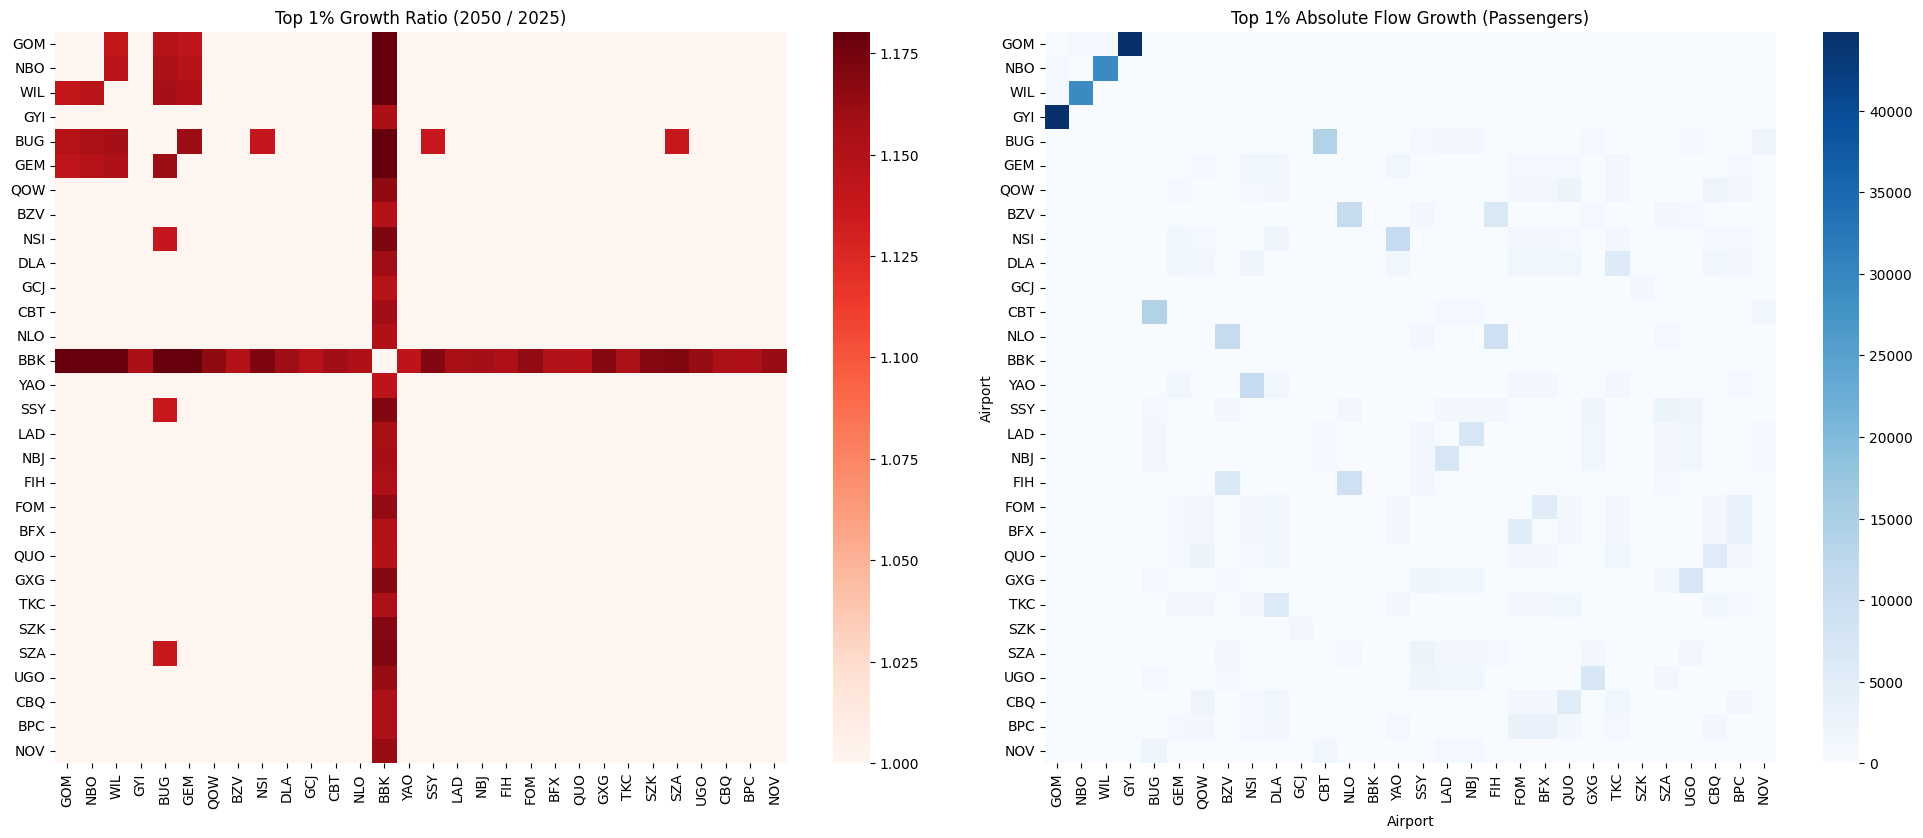

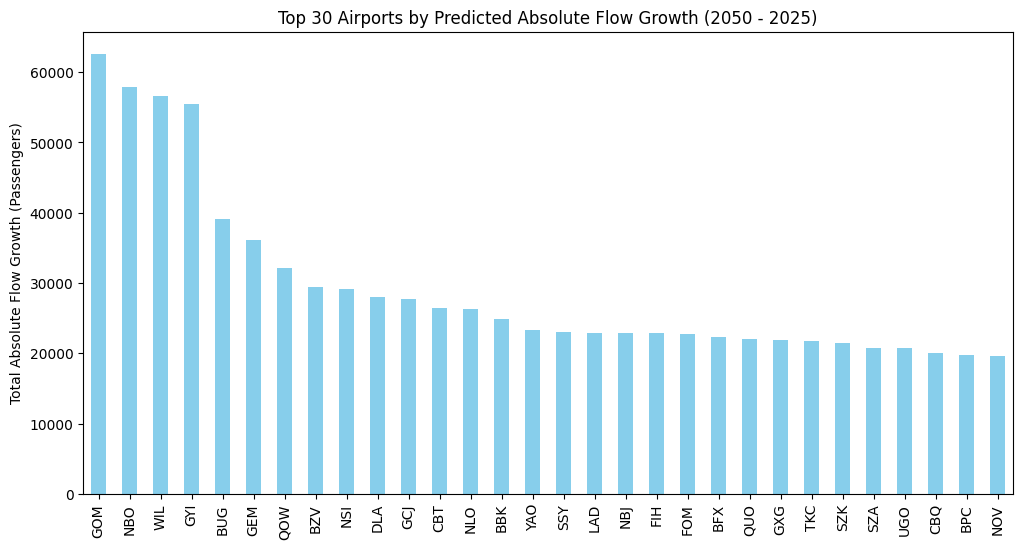

In [108]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import combinations
from shapely.geometry import LineString
import geopandas as gpd

epsilon = 1  # km, 最小距离


flows_records = []

for i, j in combinations(nodes.index, 2):
    Pi_25 = nodes.loc[i, "pop_2025"]
    Pj_25 = nodes.loc[j, "pop_2025"]
    Pi_50 = nodes.loc[i, "pop_2050"]
    Pj_50 = nodes.loc[j, "pop_2050"]
    Ii = nodes.loc[i, "GDPpercapita_2024"]
    Ij = nodes.loc[j, "GDPpercapita_2024"]

    Dij = max(nodes.loc[i, "geometry"].distance(nodes.loc[j, "geometry"])/1000, epsilon)
    if Pi_25 == 0 or Pj_25 == 0:
        continue

    # 对数缩放 + α/β
    F25 = ((np.log1p(Pi_25)*np.log1p(Ii)) * (np.log1p(Pj_25)*np.log1p(Ij)) * alpha_cal**2) / (Dij ** beta_cal)
    F50 = ((np.log1p(Pi_50)*np.log1p(Ii)) * (np.log1p(Pj_50)*np.log1p(Ij)) * alpha_cal**2) / (Dij ** beta_cal)

    growth_ratio = F50 / F25 if F25>0 else np.nan
    abs_growth = F50 - F25

    flows_records.append({
        "from_code": nodes.loc[i, "iata_code"],
        "to_code": nodes.loc[j, "iata_code"],
        "F25": F25,
        "F50": F50,
        "growth_ratio": growth_ratio,
        "abs_growth": abs_growth,
        "geometry": LineString([nodes.loc[i, "geometry"], nodes.loc[j, "geometry"]])
    })

flows_gdf = gpd.GeoDataFrame(flows_records, crs=nodes.crs)


ratio_threshold = flows_gdf["growth_ratio"].quantile(0.99)
flows_top_ratio = flows_gdf[flows_gdf["growth_ratio"] >= ratio_threshold]



abs_threshold = flows_gdf["abs_growth"].quantile(0.99)
flows_top_abs = flows_gdf[flows_gdf["abs_growth"] >= abs_threshold]


airport_abs_growth = {}
for idx, rec in flows_top_abs.iterrows():
    airport_abs_growth[rec['from_code']] = airport_abs_growth.get(rec['from_code'],0) + rec['abs_growth']
    airport_abs_growth[rec['to_code']] = airport_abs_growth.get(rec['to_code'],0) + rec['abs_growth']

airport_abs_growth_series = pd.Series(airport_abs_growth).sort_values(ascending=False)
top_airports = airport_abs_growth_series.head(30)


fig, axes = plt.subplots(1,2,figsize=(20,8))

# 5a. 热力图：增长倍数 top 30 机场
top_codes_ratio = top_airports.index.tolist()
growth_ratio_matrix = pd.DataFrame(1.0, index=top_codes_ratio, columns=top_codes_ratio)

for idx, rec in flows_top_ratio.iterrows():
    if rec['from_code'] in top_codes_ratio and rec['to_code'] in top_codes_ratio:
        growth_ratio_matrix.loc[rec['from_code'], rec['to_code']] = rec['growth_ratio']
        growth_ratio_matrix.loc[rec['to_code'], rec['from_code']] = rec['growth_ratio']

sns.heatmap(
    growth_ratio_matrix,
    cmap="Reds",
    vmax=np.nanquantile(growth_ratio_matrix.values, 0.99),
    ax=axes[0],
    square=True
)
axes[0].set_title("Top 1% Growth Ratio (2050 / 2025)")

# 5b. 热力图 + 条形图：绝对增长量
abs_growth_matrix = pd.DataFrame(0.0, index=top_codes_ratio, columns=top_codes_ratio)

for idx, rec in flows_top_abs.iterrows():
    if rec['from_code'] in top_codes_ratio and rec['to_code'] in top_codes_ratio:
        abs_growth_matrix.loc[rec['from_code'], rec['to_code']] = rec['abs_growth']
        abs_growth_matrix.loc[rec['to_code'], rec['from_code']] = rec['abs_growth']

sns.heatmap(
    abs_growth_matrix,
    cmap="Blues",
    ax=axes[1],
    square=True
)
axes[1].set_title("Top 1% Absolute Flow Growth (Passengers)")
axes[1].set_ylabel("Airport")
axes[1].set_xlabel("Airport")

plt.tight_layout()
plt.show()

# 条形图展示 top 30 机场绝对增长量
plt.figure(figsize=(12,6))
top_airports.plot(kind='bar', color='skyblue')
plt.ylabel("Total Absolute Flow Growth (Passengers)")
plt.title("Top 30 Airports by Predicted Absolute Flow Growth (2050 - 2025)")
plt.show()

In [99]:
nodes[nodes['iata_code']=='BBK'][['pop_2025','pop_2050','GDPpercapita_2024']]

,pop_2025,pop_2050,GDPpercapita_2024
410,107296.0,383617.0,7695.753194


In [100]:
# 计算绝对流量增长
flows_top_growth['abs_growth'] = flows_top_growth['F50'] - flows_top_growth['F25']

# 按机场累计绝对增长
airport_abs_growth = {}
for idx, rec in flows_top_growth.iterrows():
    airport_abs_growth[rec['from_code']] = airport_abs_growth.get(rec['from_code'],0) + rec['abs_growth']
    airport_abs_growth[rec['to_code']] = airport_abs_growth.get(rec['to_code'],0) + rec['abs_growth']

# 排序
pd.Series(airport_abs_growth).sort_values(ascending=False).head(20)

/home/liang/anaconda3/envs/ug-env/lib/python3.13/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


BBK    132957.848629
ADI    131557.392105
WIL     39760.880842
NBO     36145.599239
MXM     25986.336981
BUG     21450.895593
KMU     15745.248211
VPE     11053.164271
OND     10030.898209
GEM      9936.581316
WVB      6567.177557
BJM      6044.676202
OLL      5970.346886
SVB      5885.718198
LVI      5430.632166
THZ      5093.636531
HGA      4785.517664
MPA      4404.893248
GOM      4363.773695
ZNZ      4203.082856
dtype: float64